In [9]:
from dataloader import DataLoader
from datasets import  DummyDataset, IDXDataset, FashionMNISTDataset
from evaluator import Evaluator
from datasets.transforms import (
    Compose,
    ToFloat,
    Normalize,
    Scale,
)
from scheduler import StepLR
from datasets.utils import random_split
from layers import ReLU, Linear, Flatten, Dropout
from network import Network
from optimizers import SGD, SGDMomentum, Adam
from losses import SoftmaxCrossEntropy
from train import Trainer

import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
batch_size = 4

layers = [
    Linear(10, 150),
    ReLU(),
    Linear(150, 3)
]

train_dataset = DummyDataset(
    num_samples=20,
    num_features=10,
    num_classes=3,
    seed=42,
)

val_dataset = train_dataset

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    drop_last=False,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    drop_last=False,
    shuffle=False
)

loss_func = SoftmaxCrossEntropy()
model = Network(layers)

optimizer = Adam(
    parameters=model.parameters(), 
    learning_rate=1e-3,
    weight_decay=1e-4
)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_func=loss_func,
    optimizer=optimizer
)

history = trainer.train(epochs=60)

(Epoch 1 / 60) train loss: 1.379964; train accuracy: 0.4000; val loss: 1.232376; val accuracy: 0.5000
(Epoch 2 / 60) train loss: 1.170212; train accuracy: 0.5500; val loss: 1.082526; val accuracy: 0.6000
(Epoch 3 / 60) train loss: 1.045602; train accuracy: 0.7000; val loss: 0.963343; val accuracy: 0.7500
(Epoch 4 / 60) train loss: 0.941348; train accuracy: 0.7000; val loss: 0.872737; val accuracy: 0.7500
(Epoch 5 / 60) train loss: 0.851654; train accuracy: 0.7500; val loss: 0.803546; val accuracy: 0.7500
(Epoch 6 / 60) train loss: 0.781303; train accuracy: 0.7500; val loss: 0.747107; val accuracy: 0.7500
(Epoch 7 / 60) train loss: 0.735244; train accuracy: 0.7500; val loss: 0.693384; val accuracy: 0.7500
(Epoch 8 / 60) train loss: 0.676930; train accuracy: 0.8000; val loss: 0.649429; val accuracy: 0.8000
(Epoch 9 / 60) train loss: 0.634550; train accuracy: 0.8000; val loss: 0.606636; val accuracy: 0.8500
(Epoch 10 / 60) train loss: 0.597842; train accuracy: 0.8500; val loss: 0.566326; 

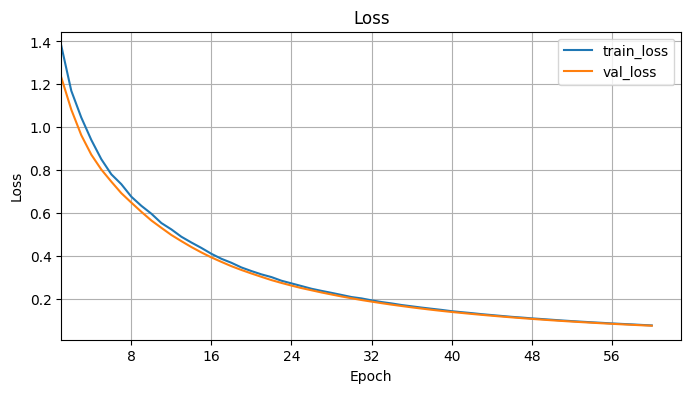

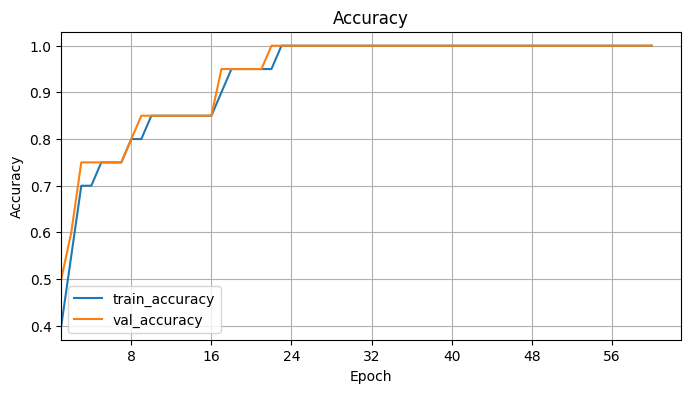

In [11]:
history.plot_loss()
history.plot_accuracy()

## Fashion MNIST dataset

In [34]:
data_path = "data/fashion-mnist/train-images-idx3-ubyte"
labels_path = "data/fashion-mnist/train-labels-idx1-ubyte"

transform = Compose([
    ToFloat(),
    Scale(255.0),
    Normalize(mean=0.2860, std=0.3530),
])

dataset = IDXDataset(
    data_path=data_path,
    labels_path=labels_path,
    transform=transform,
)

splits = random_split(
    dataset,
    {"train": 0.8, "val": 0.2},
    seed=42,
)

train_dataset = splits["train"]
val_dataset = splits["val"]

In [36]:
batch_size = 128

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

In [ ]:
model = Network([
    Flatten(),
    Linear(784, 1024),
    ReLU(),
    Dropout(0.1),

    Linear(1024, 512),
    ReLU(),
    Dropout(0.1),

    Linear(512, 10),
])

In [ ]:
lr = 1e-3
wd = 5e-5

loss_func = SoftmaxCrossEntropy()
optimizer = Adam(
    parameters=model.parameters(),
    learning_rate=1e-3,
    weight_decay=wd
)
scheduler = StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

In [43]:
epochs = 30

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_func=loss_func,
    optimizer=optimizer,
    scheduler=scheduler,
)

history = trainer.train(epochs=epochs, checkpoint_monitor="accuracy", checkpoint_mode="max")

(Epoch 1 / 30) train loss: 0.486049; train accuracy: 0.8270; val loss: 0.397392; val accuracy: 0.8571
(Epoch 2 / 30) train loss: 0.349661; train accuracy: 0.8735; val loss: 0.355112; val accuracy: 0.8662
(Epoch 3 / 30) train loss: 0.312807; train accuracy: 0.8846; val loss: 0.349265; val accuracy: 0.8722
(Epoch 4 / 30) train loss: 0.283214; train accuracy: 0.8965; val loss: 0.353953; val accuracy: 0.8696
(Epoch 5 / 30) train loss: 0.268974; train accuracy: 0.9010; val loss: 0.340994; val accuracy: 0.8763
(Epoch 6 / 30) train loss: 0.220649; train accuracy: 0.9195; val loss: 0.290936; val accuracy: 0.8938
(Epoch 7 / 30) train loss: 0.207176; train accuracy: 0.9253; val loss: 0.299884; val accuracy: 0.8924
(Epoch 8 / 30) train loss: 0.197856; train accuracy: 0.9281; val loss: 0.299123; val accuracy: 0.8913
(Epoch 9 / 30) train loss: 0.191503; train accuracy: 0.9299; val loss: 0.298665; val accuracy: 0.8925
(Epoch 10 / 30) train loss: 0.183198; train accuracy: 0.9330; val loss: 0.300824; 

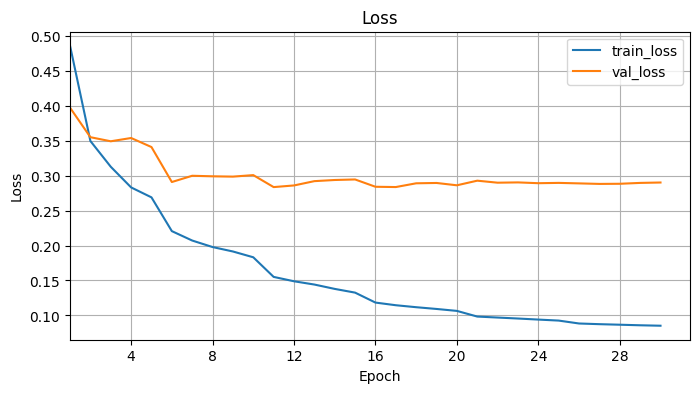

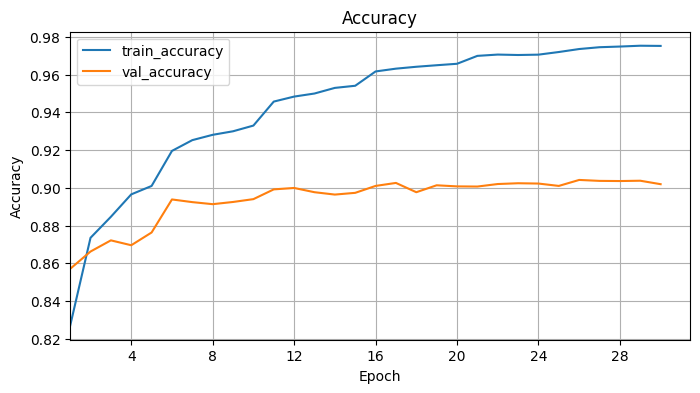

In [44]:
history.plot_loss()
history.plot_accuracy()

In [19]:
evaluator = Evaluator(
    model=model,
    class_names=FashionMNISTDataset.CLASS_NAMES
)

results = evaluator.evaluate(val_loader)

print(results["accuracy"])

0.89625


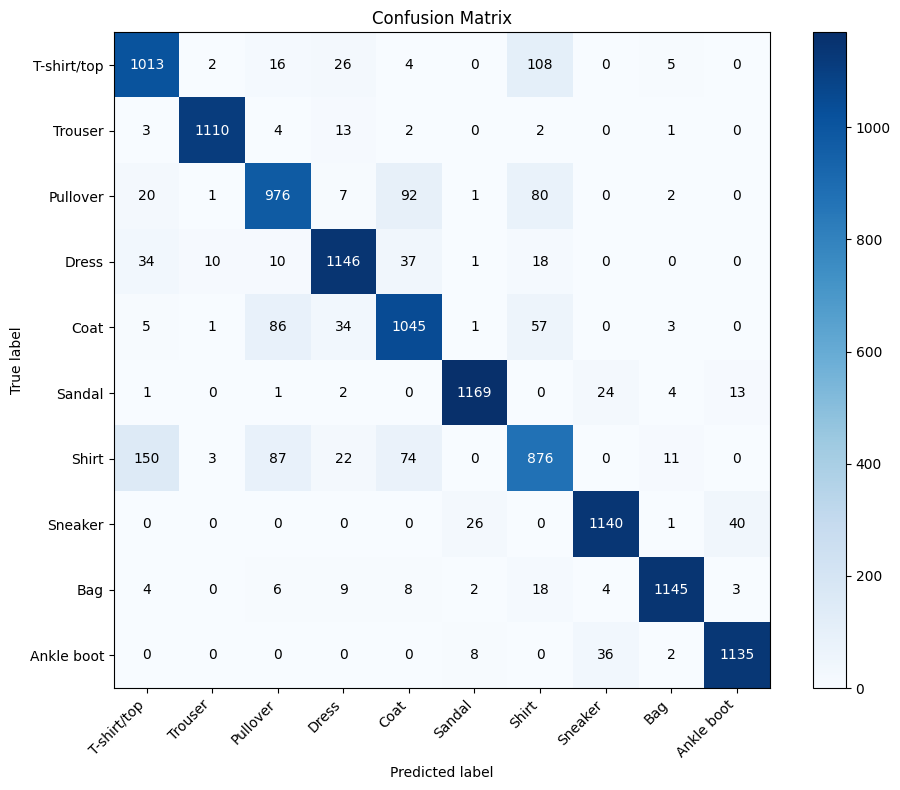

In [20]:
evaluator.plot_confusion_matrix(results)

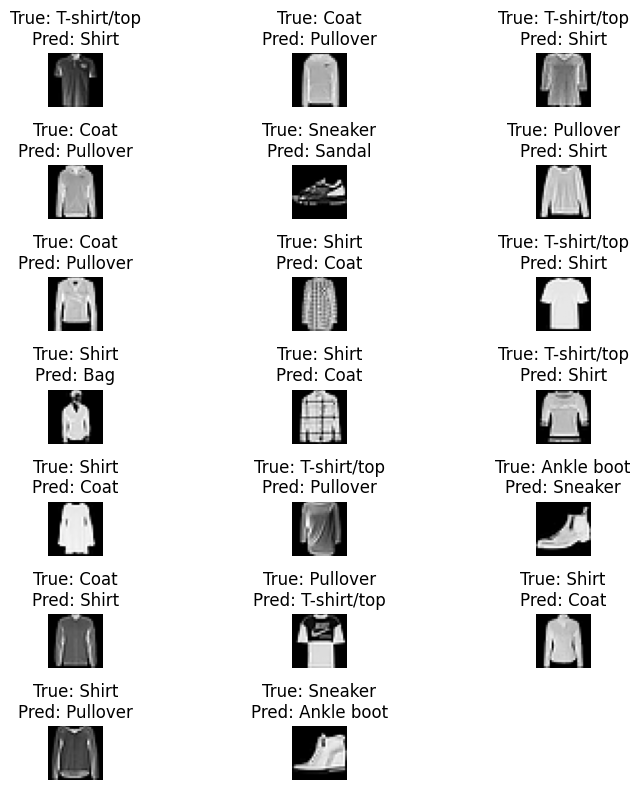

In [103]:
evaluator.plot_wrong_predictions(
    results,
    max_images=20,
    image_shape=(28, 28)
)

## Test

In [27]:
test_data_path = "data/fashion-mnist/train-images-idx3-ubyte"
test_labels_path = "data/fashion-mnist/train-labels-idx1-ubyte"

test_dataset = FashionMNISTDataset(
    data_path=test_data_path,
    labels_path=test_labels_path,
    transform=transform,
)

In [28]:
test_index = np.random.randint(len(test_dataset))

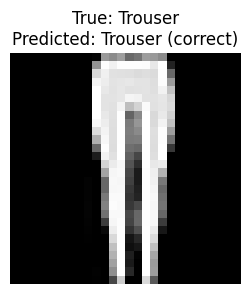

In [30]:
sample = test_dataset[test_index]
x = sample["data"]
y_true = sample["label"]

scores = model.forward(x[None, :])
y_pred = np.argmax(scores, axis=1)[0]

y_true_name = test_dataset.CLASS_NAMES[y_true]
y_pred_name = test_dataset.CLASS_NAMES[y_pred]

is_correct = y_pred == y_true
status = "correct" if is_correct else "wrong"

plt.figure(figsize=(3, 3))
plt.imshow(x.reshape(28, 28), cmap="gray")
plt.title(f"True: {y_true_name}\nPredicted: {y_pred_name} ({status})")
plt.axis("off")
plt.show()